In [1]:
import pandas as pd
import seaborn as sns
from plotnine import ggplot, aes, geom_histogram, labs, theme_minimal, scale_fill_brewer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv(
    "data/The_Cancer_data_1500_V2.csv",
    sep=","
)

In [9]:
data.head()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


In [3]:
df = data.copy()

In [4]:
df["Sexe_label"] = df["Gender"].map({0: "Homme", 1: "Femme"}) 
df["Tabac_label"] = df["Smoking"].map({0: "Non", 1: "Oui"}) 
df["Genetic_label"] = df["GeneticRisk"].map({0: "Faible", 1: "Moyen", 2: "Élevé"})
df["Diagnosis_label"] = df["Diagnosis"].map({0: "Pas de cancer", 1: "Cancer"})

In [5]:
conditions = [(df["Age"]<30),
              (df["Age"]>=30)&(df["Age"]<40),
              (df["Age"]>=40)&(df["Age"]<50),
              (df["Age"]>=50)&(df["Age"]<60),
              (df["Age"]>=60)&(df["Age"]<70),
              (df["Age"]>=70)&(df["Age"]<=80)]

choix = ["moins de 30 ans", "30 ans - 39 ans", "40 ans - 49 ans","50 ans - 59 ans","60 ans - 69 ans","70 ans - 80 ans"]
df["classe_age"] = np.select(conditions, choix, default="plus de 80 ans")

In [6]:
df.head()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis,Sexe_label,Tabac_label,Genetic_label,Diagnosis_label,classe_age
0,58,1,16.085313,0,1,8.146251,4.148219,1,1,Femme,Non,Moyen,Cancer,50 ans - 59 ans
1,71,0,30.828784,0,1,9.361630,3.519683,0,0,Homme,Non,Moyen,Pas de cancer,70 ans - 80 ans
2,48,1,38.785084,0,2,5.135179,4.728368,0,1,Femme,Non,Élevé,Cancer,40 ans - 49 ans
3,34,0,30.040296,0,0,9.502792,2.044636,0,0,Homme,Non,Faible,Pas de cancer,30 ans - 39 ans
4,62,1,35.479721,0,0,5.356890,3.309849,0,1,Femme,Non,Faible,Cancer,60 ans - 69 ans


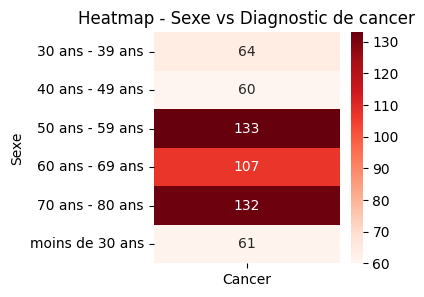

In [15]:
# Création de la table croisée
ct_cancer = pd.crosstab(df["classe_age"], df["Diagnosis"])
ct_cancer = ct_cancer[[1]]
ct_cancer.columns = ["Cancer"]

# Heatmap
plt.figure(figsize=(3,3))
sns.heatmap(ct_cancer, annot=True, fmt="d", cmap="Reds", cbar=True)
plt.title("Heatmap - Sexe vs Diagnostic de cancer")
plt.ylabel("Sexe")
#plt.xlabel("Diagnostic")
plt.show()


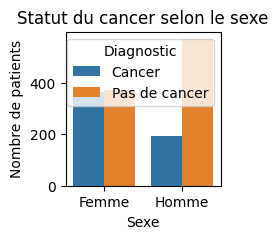

In [14]:
# Création du barplot groupé
plt.figure(figsize=(2,2))
sns.countplot(data=df, x="Sexe_label", hue="Diagnosis_label")
plt.title("Statut du cancer selon le sexe")
plt.xlabel("Sexe")
plt.ylabel("Nombre de patients")
plt.legend(title="Diagnostic")
plt.show()


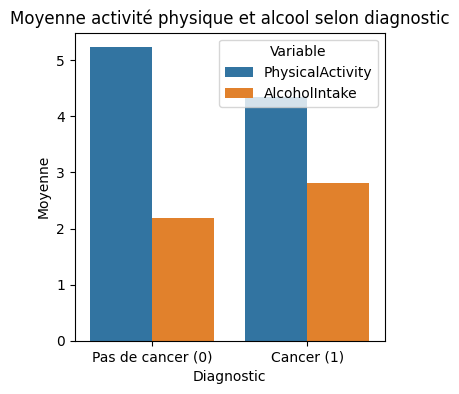

In [ ]:
# Préparer les moyennes
moyennes = df.groupby("Diagnosis")[["PhysicalActivity", "AlcoholIntake"]].mean().reset_index()

# Transformation en format long pour seaborn
moyennes_melt = moyennes.melt(id_vars="Diagnosis", var_name="Variable", value_name="Moyenne")

# Graphique barplot
plt.figure(figsize=(4, 4)) 
sns.barplot(data=moyennes_melt, x="Diagnosis", y="Moyenne", hue="Variable", errorbar="sd") 
plt.xticks([0, 1], ["Pas de cancer (0)", "Cancer (1)"]) 
plt.title("Moyenne activité physique et alcool selon diagnostic") 
plt.ylabel("Moyenne") 
plt.xlabel("Diagnostic") 
plt.legend(title="Variable") 
plt.show()
